# Making slice plots of Post-Processed data

### Import packages

In [2]:
import numpy                          as np
import matplotlib.pyplot              as plt

# import plons scriptsr
import plons
import plons.SmoothingKernelScript    as sk
import plons.PhysicalQuantities       as pq
import plons.ConversionFactors_cgs    as cgs
import plons.Plotting                 as plot

import cons 
from typing import Dict, Tuple, Any, Optional

import numpy.typing as npt
import matplotlib

import magritte.core  as magritte             # Core functionality
import os 

import astropy.constants as constants
import astropy.units as units

wdir = os.getcwd()  

## Load in the PHANTOM model and Magritte model files

In [2]:
def doall(dir, v):
    prefix = "wind"
    loc = f"{dir}/Model/"
    dump = loc + "wind_01600"
    
    if v == 20:
        dump = loc + "wind_01200"

    setup     = plons.LoadSetup(loc, prefix)
    dumpData  = plons.LoadFullDump(dump, setup)
    
    position = dumpData["position"]*1e-2      # position vectors       [cm   -> m]
    velocity = dumpData["velocity"]*1e3      # velocity vectors        [km/s -> m/s]
    velocity = velocity/constants.c.si.value # velocity vectors        [m/s  -> 1/c]
    rho      = dumpData["rho"]               # density                 [g/cm^3]
    u        = dumpData["u"]                 # internal energy density [erg/g]
    tmp      = dumpData["Tgas"]              # temperature             [K]
    tmp[tmp<2.725] = 2.725                   # Cut-off temperatures below 2.725 K

    # Convert rho (total density) to abundance
    rho_cgs = rho
    T_cgs = tmp

    kboltz = 1.380649e-16              # * units.erg / units.K  # Boltzmann constant in cgs units (erg/K)
    patm = 1.01325e6                   # * units.dyn / (units.cm**2)   # Atmospheric pressure in cgs units (dyn/cm^2)
    atomic_mass_unit = 1.660538921e-24 # * units.g
    mass_proton_cgs  = 1.6726219e-24   # * units.g

    eps = cons.get_eps()
    coefficients = cons.get_coefficients()
    molecules = np.array(list(coefficients.keys()))
    Aw_nElements = [1.0079, 4.0026, 12.011, 15.9994, 14.0067, 20.17, 28.0855, 32.06, 55.847, 47.867]

    mass_per_H = atomic_mass_unit * np.dot(Aw_nElements,np.array(list(eps.values())))

    pH_tot = rho_cgs * kboltz * T_cgs / (patm * mass_per_H) # Total hydrogen (partial) pressure

    a = 2 * cons.calc_Kd(coefficients['H2'], T_cgs)
    b = 1 
    c = -pH_tot #- (1 - 4 * eps['iHe'] * pH_tot ) / mu 
    pH = cons.solve_q(a, b, c)
    pH2 = pH**2 * cons.calc_Kd(coefficients['H2'], T_cgs)

    patm_u = patm * units.dyn / (units.cm**2)
    kboltz_u = 1.380649e-16 * units.erg / units.K
    mass_per_H_u = 1.660538921e-24 * units.g

    T_u = T_cgs * units.K
    rho_u = rho_cgs * units.g / (units.cm**3)

    pH_tot = rho_u * kboltz_u * T_u / (patm_u * mass_per_H_u)

    pH2 = pH2 * units.erg / (units.cm) / units.dyn 
    nH2_p = (pH2 * patm_u / (kboltz_u * T_u)).to(units.cm**-3)

    pH = pH * units.erg / (units.cm) / units.dyn
    nH_p = (pH * patm_u / (kboltz_u * T_u)).to(units.cm**-3)

    nH2 = nH2_p.to(units.m**-3).value
    nH  =  nH_p.to(units.m**-3).value

    # Read in the result of the final iteration of the CO photodissociation
    profiles = sorted(os.listdir(wdir + f'/{dir}/x_profiles'), key = lambda x: int(x[-1]))
    nCO = (np.loadtxt(wdir + f'/{dir}/x_profiles/{profiles[-1]}') * units.m**(-3)).to(units.m**-3).value
    
    nCO_old = 1.5e-4 * (nH + 2*nH2)
    
    dumpData[f'nCO'] = nCO
    dumpData[f'nCO_old'] = nCO_old
    dumpData[f'nH'] = nH
    dumpData[f'nH2'] = nH2
    
    return dumpData

In [3]:
v05a09 = doall("v05a09", 5)
v05a15 = doall("v05a15", 5)
v05a25 = doall("v05a25", 5)

v10a09 = doall("v10a09", 10)
v10a15 = doall("v10a15", 10)
v10a25 = doall("v10a25", 10)

v20a09 = doall("v20a09", 20)
v20a15 = doall("v20a15", 20)
v20a25 = doall("v20a25", 20)

## Define a smoothing function for the LTE and NLTE level populations

In [4]:
def get_smooth(dumpData, X, Y, Z, key):
    
    smooth = sk.smoothMesh(X, Y, Z, dumpData, [f'{key}'])
    
    # Sometimes nans occur, which messes with the colourbar... 
    return remove_nans(smooth)

def remove_nans(smooth):
    for key in smooth.keys():
        smooth[key][np.isnan(smooth[key])] = 0
    return smooth

In [5]:
def plotSlice(ax: plt.Axes,
              X: npt.NDArray[np.single],
              Y: npt.NDArray[np.single],
              smooth: Dict[str, npt.NDArray[np.single]],
              observable: str,
              logplot: bool = False,
              fs : int = 16,
              cbar : bool = False,
              cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('inferno'),
              clim: Tuple[Optional[float], Optional[float]] = (None, None)) -> matplotlib.colorbar.Colorbar:
    """Plot a property given a grid and smoothed data ontop of the grid

    Args:
        ax (plt.Axes): axis of figure on which you want to plot the slice
        X (npt.NDArray[np.single]): X values in meshgrid which you want to plot
        Y (npt.NDArray[np.single]): Y values in meshgrid which you want to plot
        smooth (Dict[str, npt.NDArray[np.single]]): Dictionary pointing at smoothed values in meshgrid which you want to plot
        observable (str): Name of the observable you want to plot, corresponding to the name in the smooth directory
        logplot (bool, optional): plot in log scale?. Defaults to False.
        cmap (matplotlib.colors.Colormap, optional): Colormap to use. Defaults to cm.get_cmap('inferno').
        clim (Tuple[Optional[float], Optional[float]], optional): limits for the colorbar. Defaults to (None, None).

    Returns:
        colorbar.Colorbar: Colorbar
    """

    ax.set_aspect('equal')
    ax.set_facecolor('k')

    if logplot:
        obs = np.log10(smooth[observable]+1e-99)
    else:
        obs = smooth[observable]
    axPlot = ax.pcolormesh(X/cgs.au, Y/cgs.au, obs, cmap=cmap, vmin=clim[0], vmax = clim[1], shading='gouraud')
    
    if cbar == True:
        cbar = plt.colorbar(axPlot, ax = ax, location='right', fraction=0.0471, pad=0.01)  
        cbar.ax.tick_params(labelsize=fs-4)          
        return cbar

/var/folders/w_/4_pt99l91872mmqb2qmdz070dpkh4n/T/ipykernel_30403/4251809695.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('inferno'),


## Create slices in both the xy and xz plane

In [6]:
500*500 * 9 

2250000

In [7]:
n = 600
lims = 6000  # To where to plot in AU

x = np.linspace(-lims, lims, n)*cgs.au
z = np.linspace(-lims, lims, n)*cgs.au
X, Z = np.meshgrid(x, z)
Y = np.zeros_like(X)

In [8]:
def do(dumpData, lims, n):
    
    x = np.linspace(-lims, lims, n)*cgs.au
    z = np.linspace(-lims, lims, n)*cgs.au
    X, Z = np.meshgrid(x, z)
    Y = np.zeros_like(X)
    
    nCO_z = get_smooth(dumpData, X, Y, Z, 'nCO')
    nCO_old_z = get_smooth(dumpData, X, Y, Z, 'nCO_old')

    nH2_z = get_smooth(dumpData, X, Y, Z, 'nH2')
    nH_z = get_smooth(dumpData, X, Y, Z, 'nH')

    ratio_xy = nCO_z['nCO'] / (nH_z['nH'] + 2 * nH2_z['nH2'])
    ratio_xy[np.isnan(ratio_xy)] = 0
    
    return nCO_z, nCO_old_z, ratio_xy

In [9]:
nCO_z_v05a09, nCO_old_z_v05a09, ratio_xy_v05a09 = do(v05a09, lims, n)
nCO_z_v05a15, nCO_old_z_v05a15, ratio_xy_v05a15 = do(v05a15, lims, n)
nCO_z_v05a25, nCO_old_z_v05a25, ratio_xy_v05a25 = do(v05a25, lims, n)

nCO_z_v10a09, nCO_old_z_v10a09, ratio_xy_v10a09 = do(v10a09, lims, n)
nCO_z_v10a15, nCO_old_z_v10a15, ratio_xy_v10a15 = do(v10a15, lims, n)
nCO_z_v10a25, nCO_old_z_v10a25, ratio_xy_v10a25 = do(v10a25, lims, n)

nCO_z_v20a09, nCO_old_z_v20a09, ratio_xy_v20a09 = do(v20a09, lims, n)
nCO_z_v20a15, nCO_old_z_v20a15, ratio_xy_v20a15 = do(v20a15, lims, n)
nCO_z_v20a25, nCO_old_z_v20a25, ratio_xy_v20a25 = do(v20a25, lims, n)

/var/folders/w_/4_pt99l91872mmqb2qmdz070dpkh4n/T/ipykernel_30403/557311251.py:14: RuntimeWarning: invalid value encountered in divide
  ratio_xy = nCO_z['nCO'] / (nH_z['nH'] + 2 * nH2_z['nH2'])


In [10]:
matplotlib.rcParams["font.size"] = "10"
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

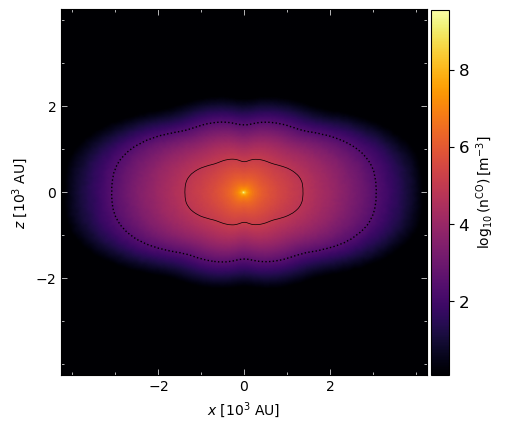

In [11]:
fig, ax11 = plt.subplots(1, 1, figsize=(5, 5))

fac = 100

cbar = plotSlice(ax11, X, Z, nCO_z_v05a09, f'nCO', logplot = True, cmap = plt.colormaps['inferno'], cbar = True,
          clim=( np.log10( np.amax(nCO_z_v05a09['nCO']) ) / fac, np.log10( np.amax(nCO_z_v05a09['nCO']) ) ) )

cbar.set_label(r"$\log_{10}(\mathrm{n}^{\mathrm{CO}}) \, [\mathrm{m}^{-3}]$")

ax11.contour(X/cgs.au, Z/cgs.au, ratio_xy_v05a09, levels=[np.amax(ratio_xy_v05a09) / 100, np.amax(ratio_xy_v05a09) / 2], 
             colors=['black', 'black'], linestyles=[':', '-'], linewidths=[1, 0.5])

ax11.set_ylabel("$z$ [$10^3$ AU]")
ax11.set_xlabel("$x$ [$10^3$ AU]")

L = 4250
    
ax11.set_xlim(-L, L)
ax11.set_ylim(-L, L)

ax11.set_xticks([-2000, 0, 2000], ['$-2$', '$0$', '$2$'])
ax11.set_yticks([-2000, 0, 2000], ['$-2$', '$0$', '$2$'])

ax11.tick_params(axis='both', which='major', direction='in', length=4, width=0.5, colors='white', top=True, right=True)
ax11.tick_params(axis='both', which='minor', direction='in', length=2, width=0.5, colors='white', top=True, right=True)
ax11.xaxis.set_tick_params(labelcolor='black')
ax11.yaxis.set_tick_params(labelcolor='black')
ax11.minorticks_on()
ax11.xaxis.set_minor_locator(AutoMinorLocator(2))
ax11.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.show()

In [12]:
import matplotlib.gridspec as gridspec
import matplotlib.cm                  as cm

In [13]:
def plotSlice(ax: plt.Axes,
              X: npt.NDArray[np.single],
              Y: npt.NDArray[np.single],
              smooth: Dict[str, npt.NDArray[np.single]],
              observable: str,
              logplot: bool = False,
              fs : int = 16,
              cbar : bool = False,
              cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('inferno'),
              clim: Tuple[Optional[float], Optional[float]] = (None, None)) -> matplotlib.colorbar.Colorbar:
    """Plot a property given a grid and smoothed data ontop of the grid

    Args:
        ax (plt.Axes): axis of figure on which you want to plot the slice
        X (npt.NDArray[np.single]): X values in meshgrid which you want to plot
        Y (npt.NDArray[np.single]): Y values in meshgrid which you want to plot
        smooth (Dict[str, npt.NDArray[np.single]]): Dictionary pointing at smoothed values in meshgrid which you want to plot
        observable (str): Name of the observable you want to plot, corresponding to the name in the smooth directory
        logplot (bool, optional): plot in log scale?. Defaults to False.
        cmap (matplotlib.colors.Colormap, optional): Colormap to use. Defaults to cm.get_cmap('inferno').
        clim (Tuple[Optional[float], Optional[float]], optional): limits for the colorbar. Defaults to (None, None).

    Returns:
        colorbar.Colorbar: Colorbar
    """

    ax.set_aspect('equal')
    ax.set_facecolor('k')

    if logplot:
        obs = np.log10(smooth[observable]+1e-99)
    else:
        obs = smooth[observable]
    axPlot = ax.pcolormesh(X/cgs.au, Y/cgs.au, obs, cmap=cmap, vmin=clim[0], vmax = clim[1], shading='gouraud', rasterized=True)
    
    if cbar == True:
        cbar = plt.colorbar(axPlot, ax = ax, location='right', fraction=0.0471, pad=0.01)  
        cbar.ax.tick_params(labelsize=fs-4)          
        return cbar

/var/folders/w_/4_pt99l91872mmqb2qmdz070dpkh4n/T/ipykernel_30403/333618330.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap: matplotlib.colors.Colormap = plt.cm.get_cmap('inferno'),


In [ ]:
plt.rcParams.update({'font.size': 15}) #13

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.family"] = "sans"

plt.rcParams["text.usetex"] = True

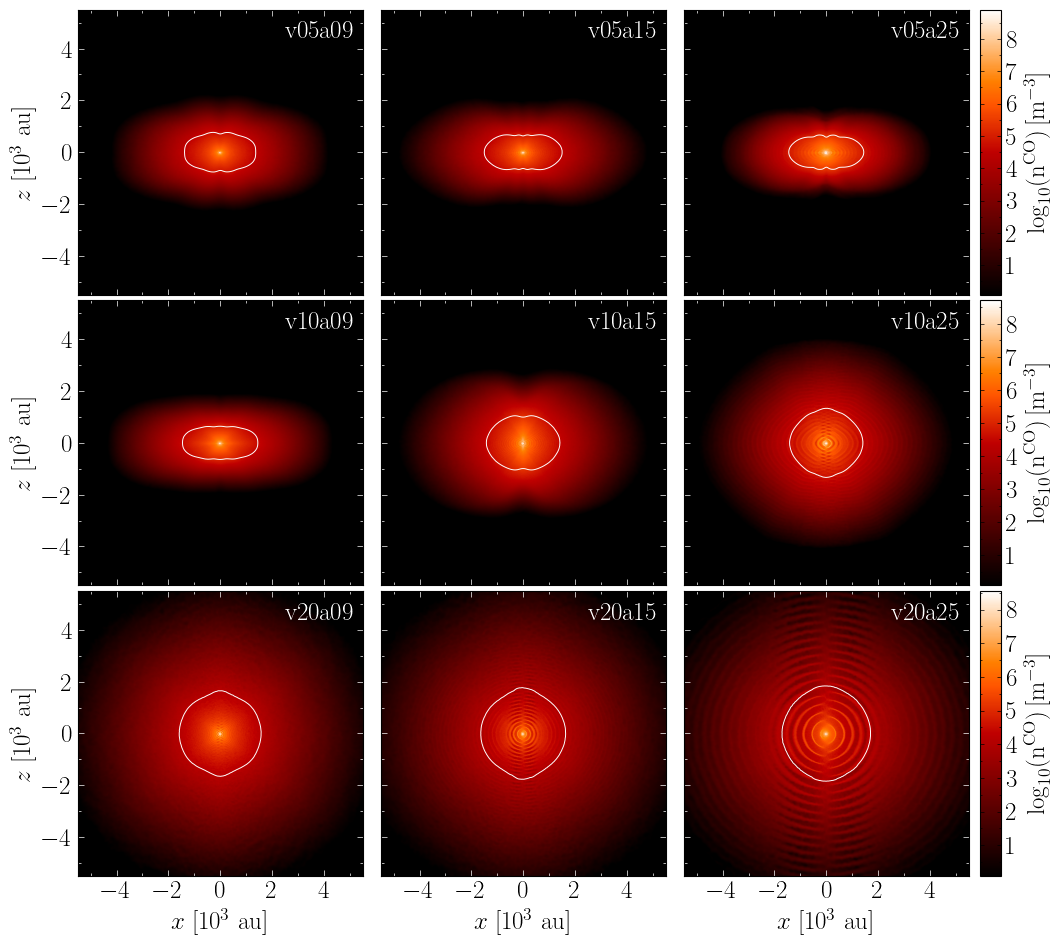

In [ ]:
fig = plt.figure(figsize=(12, 3 / 2 * 7.5))

lims_list = [4250, 4250, 4250, 4500, 4500, 4500, 6000, 6000, 6000]

lims_list = [5500] * 9

# Define a grid with extra space for colorbars
gs = gridspec.GridSpec(3, 4, width_ratios=[1, 1, 1, 0.07], wspace=0.02, hspace=0.02)

# Create axes for subplots
ax11 = fig.add_subplot(gs[0, 0])
ax12 = fig.add_subplot(gs[0, 1])
ax13 = fig.add_subplot(gs[0, 2])
ax21 = fig.add_subplot(gs[1, 0])
ax22 = fig.add_subplot(gs[1, 1])
ax23 = fig.add_subplot(gs[1, 2])
ax31 = fig.add_subplot(gs[2, 0])
ax32 = fig.add_subplot(gs[2, 1])
ax33 = fig.add_subplot(gs[2, 2])

cmap = plt.cm.gist_heat

strings = ['v05a09', 'v05a15', 'v05a25', 'v10a09', 'v10a15', 'v10a25', 'v20a09', 'v20a15', 'v20a25']

# Plot data in subplots
for i, (ax, data, lims, ratio, string) in enumerate( zip(
        [ax11, ax12, ax13, ax21, ax22, ax23, ax31, ax32, ax33],
        [nCO_z_v05a09, nCO_z_v05a15, nCO_z_v05a25, 
         nCO_z_v10a09, nCO_z_v10a15, nCO_z_v10a25, 
         nCO_z_v20a09, nCO_z_v20a15, nCO_z_v20a25],
        lims_list, 
        [ratio_xy_v05a09, ratio_xy_v05a15, ratio_xy_v05a25,
         ratio_xy_v10a09, ratio_xy_v10a15, ratio_xy_v10a25,
         ratio_xy_v20a09, ratio_xy_v20a15, ratio_xy_v20a25],
        strings
        ) ):
    
    n = 600
    lims = 6000  # To where to plot in AU

    x = np.linspace(-lims, lims, n)*cgs.au
    z = np.linspace(-lims, lims, n)*cgs.au
    X, Z = np.meshgrid(x, z)
    Y = np.zeros_like(X)
    
    if i not in [0, 1, 2, 3, 4, 5]:
        fac = 100
    else: 
        fac = 200

    plotSlice(ax, X, Z, data, f'nCO', logplot = True, cmap = cmap, cbar = False,
            clim=( np.log10( np.amax(data['nCO']) ) / fac, np.log10( np.amax(data['nCO']) ) ) )

    ax.contour(X/cgs.au, Z/cgs.au, ratio, levels=[np.amax(ratio) / 100, np.amax(ratio) / 2], 
                    colors=['white', 'white'], linestyles=[':', '-'], linewidths=[1.3, 0.7])
    
    ax.contour(X/cgs.au, Z/cgs.au, ratio, levels=[np.amax(ratio) / 2], 
                    colors=['white'], linestyles=['-'], linewidths=[0.7])

    L = lims_list[i]

    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_xticks([-4000, -2000, 0, 2000, 4000], ['$-4$', '$-2$', '$0$', '$2$', '$4$'])
    ax.set_yticks([-4000, -2000, 0, 2000, 4000], ['$-4$', '$-2$', '$0$', '$2$', '$4$'])
    ax.tick_params(axis='both', which='major', direction='in', length=4, width=0.5, colors='white', top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', length=2, width=0.5, colors='white', top=True, right=True)
    ax.xaxis.set_tick_params(labelcolor='black')
    ax.yaxis.set_tick_params(labelcolor='black')
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    fig.text(0.85, 0.9, f'{string }', color = 'white', ha='center', transform = ax.transAxes, fontsize = 18)
    
    if ax in [ax31, ax32, ax33]:
        ax.set_xlabel(r"$x$ [$10^3$ au]")
    else:
        ax.set_xticklabels([])
    if ax in [ax11, ax21, ax31]:
        ax.set_ylabel(r"$z$ [$10^3$ au]")
    else: 
        ax.set_yticklabels([])
        
# Add colorbars to the right column
for i, (ax, data) in enumerate(zip([ax13, ax23, ax33],
        [nCO_z_v05a25, nCO_z_v10a25, nCO_z_v20a25])):
    
    norm = matplotlib.colors.Normalize(vmin= np.log10( np.amax(data['nCO']) ) / fac, vmax=np.log10( np.amax(data['nCO'])))
    cax = fig.add_subplot(gs[i, 3])  # Colorbar axes
    cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation="vertical")
    cbar.set_label(r"$\log_{10}(\mathrm{n}^{\mathrm{CO}}) \, [\mathrm{m}^{-3}]$")
    cbar.ax.tick_params()
    
    cbar.ax.tick_params(direction='in', length=3, width=0.5, colors='k', which='major')
    cbar.ax.tick_params(direction='in', length=1.5, width=0.5, colors='k', which='minor')
    cbar.ax.tick_params(axis='y', which='both', direction='in', left=True, right=True)
        
    cbar.ax.yaxis.set_tick_params(labelcolor='black')

    cbar.ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    cbar.ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.5))
        
    cbar.ax.tick_params(axis='y', which='minor', labelleft=False, labelright=False)

plt.show()

cmap = '_gist_heat'

#fig.savefig(f"Figures/CO_density_3x3{cmap}.png", bbox_inches='tight', dpi=600)
fig.savefig(f"Figures/CO_density_3x3{cmap}_present.pdf", bbox_inches='tight', dpi=300)